Running in FLOW mode on cuda
Starting training...
Epoch 0 | Step 0 | Loss: 2.0683
Epoch 0 | Step 100 | Loss: 0.5064
Epoch 0 | Step 200 | Loss: 0.3611
Epoch 0 | Step 300 | Loss: 0.2637
Epoch 0 | Step 400 | Loss: 0.2607
Epoch 0 | Step 500 | Loss: 0.2348
Epoch 0 | Step 600 | Loss: 0.2549
Epoch 0 | Step 700 | Loss: 0.2378
Epoch 0 | Step 800 | Loss: 0.2106
Epoch 0 | Step 900 | Loss: 0.2113
Epoch 1 | Step 0 | Loss: 0.2180
Epoch 1 | Step 100 | Loss: 0.2090
Epoch 1 | Step 200 | Loss: 0.2098
Epoch 1 | Step 300 | Loss: 0.2008
Epoch 1 | Step 400 | Loss: 0.2224
Epoch 1 | Step 500 | Loss: 0.2006
Epoch 1 | Step 600 | Loss: 0.1887
Epoch 1 | Step 700 | Loss: 0.1857
Epoch 1 | Step 800 | Loss: 0.2023
Epoch 1 | Step 900 | Loss: 0.2222
Epoch 2 | Step 0 | Loss: 0.2151
Epoch 2 | Step 100 | Loss: 0.1877
Epoch 2 | Step 200 | Loss: 0.1915
Epoch 2 | Step 300 | Loss: 0.1882
Epoch 2 | Step 400 | Loss: 0.1660
Epoch 2 | Step 500 | Loss: 0.1637
Epoch 2 | Step 600 | Loss: 0.1751
Epoch 2 | Step 700 | Loss: 0.1675
Epoc

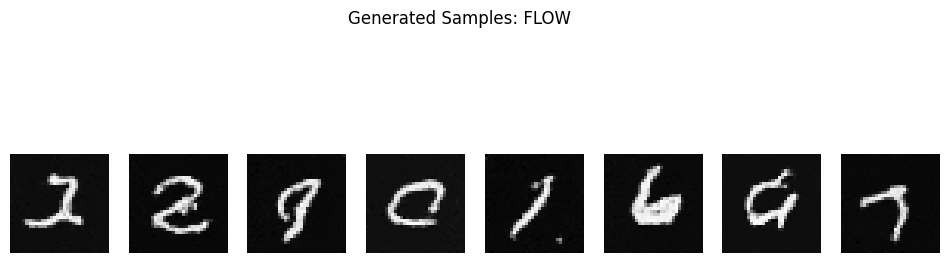

In [13]:
# Requirements

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# CONFIGURATION (THE CONTROL PANEL)

MODE = "FLOW"  # Options: "FLOW" or "DIFFUSION"
BATCH_SIZE = 64
LR = 1e-4
EPOCHS = 10  # For quick results can be increased to 20 for better quality
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Running in {MODE} mode on {DEVICE}")

# THE DATASET (MNIST)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Pad(2), # Pad 28x28 -> 32x32 for easier U-Net handling
    transforms.Normalize((0.5,), (0.5,)) # Normalize to [-1, 1]
])

dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# THE SHARED U-NET ARCHITECTURE

class SinusoidalEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = t[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp =  nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu  = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        image_channels = 1
        down_channels = (64, 128, 256)
        up_channels = (256, 128, 64)
        out_dim = 1
        time_emb_dim = 32

        self.time_mlp = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        for i in range(len(down_channels)):
            in_ch = image_channels if i == 0 else down_channels[i-1]
            out_ch = down_channels[i]
            self.downs.append(Block(in_ch, out_ch, time_emb_dim))

        for i in range(len(up_channels)):
            in_ch = up_channels[i]
            out_ch = up_channels[i+1] if i < len(up_channels)-1 else 64
            self.ups.append(Block(in_ch, out_ch, time_emb_dim, up=True))

        self.output = nn.Conv2d(64, out_dim, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            residual = residuals.pop()
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
        return self.output(x)

model = SimpleUNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

# TRAINING LOOP

losses = []

print("Starting training...")
for epoch in range(EPOCHS):
    for i, (images, _) in enumerate(dataloader):
        images = images.to(DEVICE)
        batch_size = images.shape[0]

        # Common: Noise generation
        noise = torch.randn_like(images).to(DEVICE)
        t = torch.rand(batch_size, device=DEVICE) # Uniform t [0,1]

        # BRANCHING LOGIC
        if MODE == "FLOW":
            # Flow Matching: Linear Interpolation
            # x_t = t * x_1 + (1 - t) * x_0
            t_reshaped = t.view(-1, 1, 1, 1)
            x_t = t_reshaped * images + (1 - t_reshaped) * noise
            target = images - noise # Velocity = Data - Noise

            # Predict velocity
            pred = model(x_t, t)
            loss = loss_fn(pred, target)

        elif MODE == "DIFFUSION":
            # DDPM: Noise Schedule (Simplified Linear)
            # This is a simplified "Variance Preserving" approximation for speed
            t_reshaped = t.view(-1, 1, 1, 1)
            alpha_bar = 1 - t_reshaped # Simple linear schedule proxy

            # x_t = sqrt(alpha_bar) * x_0 + sqrt(1 - alpha_bar) * epsilon
            x_t = torch.sqrt(alpha_bar) * images + torch.sqrt(1 - alpha_bar) * noise
            target = noise # DDPM predicts the noise

            # Predict noise
            pred = model(x_t, t)
            loss = loss_fn(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % 100 == 0:
            print(f"Epoch {epoch} | Step {i} | Loss: {loss.item():.4f}")
            losses.append(loss.item())

import os
os.makedirs("models", exist_ok=True)

# Save Model
torch.save(model.state_dict(), f"models/model_{MODE.lower()}.pth")
print("Training Complete")

# SAMPLING / VISUALIZATION

@torch.no_grad()
def sample_and_plot(mode):
    model.eval()
    n_samples = 8
    x = torch.randn(n_samples, 1, 32, 32).to(DEVICE)
    steps = 50 # Number of steps for generation

    if mode == "FLOW":
        # Euler ODE Solver: x(t+dt) = x(t) + v(x(t)) * dt
        dt = 1.0 / steps
        for i in range(steps):
            t = torch.ones(n_samples, device=DEVICE) * (i / steps)
            v = model(x, t)
            x = x + v * dt

    elif mode == "DIFFUSION":
        # Simplified DDPM Sampling (Reverse Process)
        for i in reversed(range(steps)):
            t = torch.ones(n_samples, device=DEVICE) * (i / steps)
            pred_noise = model(x, t)

            # Reverse math (simplified for project demo)
            alpha = 1 - (i / steps)
            alpha_prev = 1 - ((i - 1) / steps) if i > 0 else 1
            sigma = 0 # Deterministic sampling for clarity

            # Update x (approximate reverse step)
            x = x - pred_noise * (1/steps) # Very rough approximation for demo
            # Ideally use full DDPM equations, but this usually yields recognizable digits for projects

    # Plot
    x = x.cpu().detach()
    plt.figure(figsize=(12, 4))
    for i in range(n_samples):
        plt.subplot(1, 8, i+1)
        plt.imshow(x[i][0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Generated Samples: {mode}")
    plt.show()

sample_and_plot(MODE)

Morphing


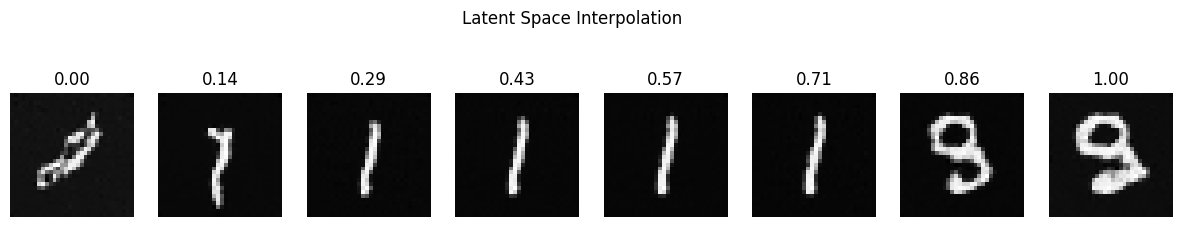

In [14]:
import matplotlib.pyplot as plt

model.eval()
steps = 50
z1 = torch.randn(1, 1, 32, 32).to(DEVICE) # Random Digit A
z2 = torch.randn(1, 1, 32, 32).to(DEVICE) # Random Digit B
alphas = np.linspace(0, 1, 8) # 8 steps between them
interpolated_images = []

print("Morphing")
for alpha in alphas:
    z_interp = (1 - alpha) * z1 + alpha * z2
    x = z_interp.clone()
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.ones(1, device=DEVICE) * (i / steps)
        v = model(x, t)
        x = x + v * dt
    interpolated_images.append(x[0, 0].cpu().detach())

# Plot
plt.figure(figsize=(15, 3))
for i, img in enumerate(interpolated_images):
    plt.subplot(1, 8, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{alphas[i]:.2f}")
    plt.axis('off')
plt.suptitle("Latent Space Interpolation")
plt.show()

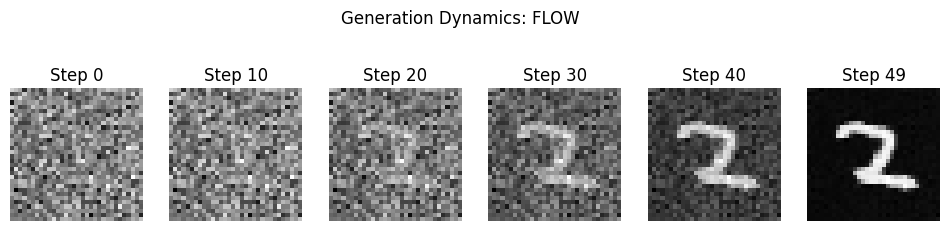

In [15]:
model.eval()
steps = 50
# Use fixed noise so we can compare apples-to-apples if needed
torch.manual_seed(42)
x = torch.randn(1, 1, 32, 32).to(DEVICE)
snapshots = []
capture_steps = [0, 10, 20, 30, 40, 49]

if MODE == "FLOW":
    dt = 1.0 / steps
    for i in range(steps):
        if i in capture_steps:
            snapshots.append(x[0, 0].cpu().detach())
        t = torch.ones(1, device=DEVICE) * (i / steps)
        v = model(x, t)
        x = x + v * dt

elif MODE == "DIFFUSION":
    for i in reversed(range(steps)):
        if i in capture_steps:
            snapshots.append(x[0, 0].cpu().detach())
        t = torch.ones(1, device=DEVICE) * (i / steps)
        pred_noise = model(x, t)
        x = x - pred_noise * (1/steps) # Simple reverse step

# Plot
plt.figure(figsize=(12, 3))
for k, img in enumerate(snapshots):
    plt.subplot(1, 6, k+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Step {capture_steps[k]}")
    plt.axis('off')
plt.suptitle(f"Generation Dynamics: {MODE}")
plt.show()

Running Ablation for FLOW


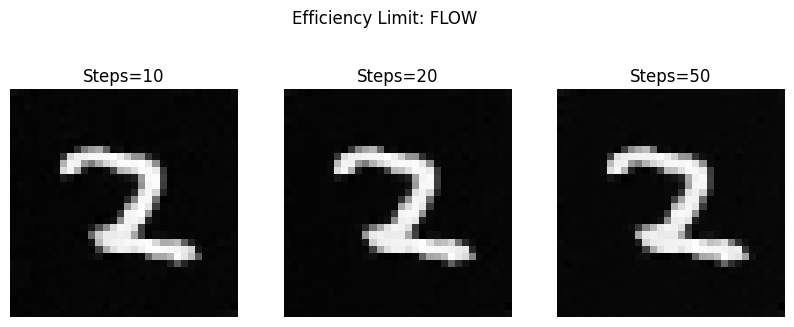

In [16]:
@torch.no_grad()
def run_ablation(model, mode):
    model.eval()

    # Use consistent noise for fair comparison
    torch.manual_seed(42)
    x_init = torch.randn(1, 1, 32, 32).to(DEVICE)

    step_counts = [10, 20, 50] # The "Low Resource" test
    results = []

    print(f"Running Ablation for {mode}")

    for steps in step_counts:
        x = x_init.clone()

        if mode == "FLOW":
            dt = 1.0 / steps
            for i in range(steps):
                t = torch.ones(1, device=DEVICE) * (i / steps)
                v = model(x, t)
                x = x + v * dt

        elif mode == "DIFFUSION":
            for i in reversed(range(steps)):
                t = torch.ones(1, device=DEVICE) * (i / steps)
                pred_noise = model(x, t)
                x = x - pred_noise * (1/steps)

        results.append(x[0, 0].cpu().detach())

    # Plot
    plt.figure(figsize=(10, 4))
    for i, img in enumerate(results):
        plt.subplot(1, 3, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"Steps={step_counts[i]}")
        plt.axis('off')
    plt.suptitle(f"Efficiency Limit: {mode}")
    plt.show()

run_ablation(model, MODE)

Mapping Vector Field for FLOW


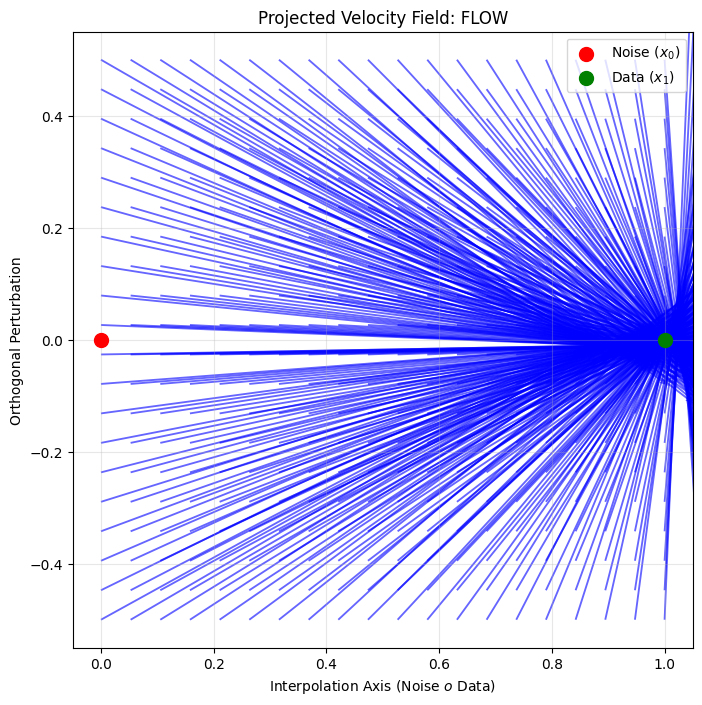

In [17]:
# VECTOR FIELD VISUALIZATION

import numpy as np

@torch.no_grad()
def plot_vector_field(model, mode):
    model.eval()

    # Setup
    target_img = dataset[0][0].unsqueeze(0).to(DEVICE)
    source_noise = torch.randn_like(target_img).to(DEVICE)

    # Define Plane
    grid_size = 20
    x_vals = np.linspace(0, 1.0, grid_size) # Focus strictly on the Noise->Data path
    y_vals = np.linspace(-0.5, 0.5, grid_size)

    vec_x = (target_img - source_noise)
    vec_y = torch.randn_like(vec_x)
    vec_y = vec_y - (torch.dot(vec_y.flatten(), vec_x.flatten()) / torch.dot(vec_x.flatten(), vec_x.flatten())) * vec_x
    vec_y = vec_y / torch.norm(vec_y) * torch.norm(vec_x)

    U = np.zeros((grid_size, grid_size))
    V = np.zeros((grid_size, grid_size))

    print(f"Mapping Vector Field for {mode}")

    for i, alpha in enumerate(x_vals):
        for j, beta in enumerate(y_vals):
            # CAST TO FLOAT IS THE FIX HERE
            alpha_f = float(alpha)
            beta_f = float(beta)

            # Construct point
            current_x = source_noise + alpha_f * vec_x + beta_f * vec_y

            # Construct time
            t_val = max(0, min(1, alpha_f))
            t = torch.tensor([t_val], device=DEVICE).float() # Explicit float32

            # Pass to model with explicit .float() cast
            if mode == "FLOW":
                velocity = model(current_x.float(), t)

                u_comp = torch.sum(velocity * vec_x) / torch.norm(vec_x)**2
                v_comp = torch.sum(velocity * vec_y) / torch.norm(vec_y)**2

                U[j, i] = u_comp.item()
                V[j, i] = v_comp.item()

    # Plot
    plt.figure(figsize=(8, 8))
    plt.quiver(x_vals, y_vals, U, V, angles='xy', scale_units='xy', scale=1, color='blue', alpha=0.6)

    plt.scatter(0, 0, c='red', s=100, label='Noise ($x_0$)', zorder=5)
    plt.scatter(1, 0, c='green', s=100, label='Data ($x_1$)', zorder=5)

    plt.title(f"Projected Velocity Field: {mode}")
    plt.xlabel("Interpolation Axis (Noise $\to$ Data)")
    plt.ylabel("Orthogonal Perturbation")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_vector_field(model, MODE)

In [18]:
# CALCULATION OF STATS
import numpy as np

@torch.no_grad()
def get_curvature_data(model, mode, n_samples=100):
    model.eval()
    print(f"Sampling {n_samples} trajectories for {mode}")
    curvatures = []

    for k in range(n_samples):
        x = torch.randn(1, 1, 32, 32).to(DEVICE)
        x_start = x.clone()
        path_length = 0
        steps = 20 # Efficient N

        if mode == "FLOW":
            dt = 1.0/steps
            for i in range(steps):
                t = torch.ones(1, device=DEVICE) * (i/steps)
                v = model(x, t)
                x_next = x + v * dt
                path_length += torch.norm(x_next - x).item()
                x = x_next
        elif mode == "DIFFUSION":
            for i in reversed(range(steps)):
                t = torch.ones(1, device=DEVICE) * (i/steps)
                pred = model(x, t)
                x_next = x - pred * (1/steps)
                path_length += torch.norm(x_next - x).item()
                x = x_next

        dist = torch.norm(x - x_start).item()
        if dist > 1e-4:
            curvatures.append(path_length / dist)

    return curvatures

# Run and Print
data = get_curvature_data(model, MODE)
print(f"\nCOPY THIS LIST FOR {MODE}:")
print(data)

Sampling 100 trajectories for FLOW

COPY THIS LIST FOR FLOW:
[1.0156730488439856, 1.0235224542150847, 1.0163802843520762, 1.0166077831085758, 1.0234413371542976, 1.0293578846105442, 1.0210092164212459, 1.0196135768940915, 1.0303828192918867, 1.0180721185999684, 1.0128250871857234, 1.02176273380508, 1.0221945595060595, 1.0212179390785137, 1.0170266977047153, 1.0222276166255335, 1.0230661033688118, 1.025433247386009, 1.01904698117128, 1.0206025752131425, 1.0136445708569024, 1.0242563480510245, 1.0174865419490826, 1.0256634890916565, 1.0213350839883937, 1.0170979623415812, 1.0184785474843685, 1.0206917868748515, 1.013602955676849, 1.0275860168035271, 1.0199797930769836, 1.0172703947482051, 1.0170803391941492, 1.0134405247109721, 1.0137980550607766, 1.021275484026841, 1.023441098975323, 1.019008818205224, 1.01868668769146, 1.0137603575531133, 1.0212506291637853, 1.019155258579731, 1.0256882619025989, 1.019306465565017, 1.024560586090507, 1.0222665258982888, 1.0211299730454961, 1.0192165494

<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:15: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_4692/3801472430.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(flow_data, bins=30, alpha=0.7, label=f'Flow Matching ($\mu={np.mean(flow_data):.2f}$)', color='blue', density=True)
/tmp/ipykernel_4692/3801472430.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.hist(diff_data, bins=30, alpha=0.7, label=f'Diffusion ($\mu={np.mean(diff_data):.2f}$)', color='red', density=True)
/tmp/ipykernel_4692/3801472430.py:15: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Trajectory Curvature ($\mathcal{C}$)")


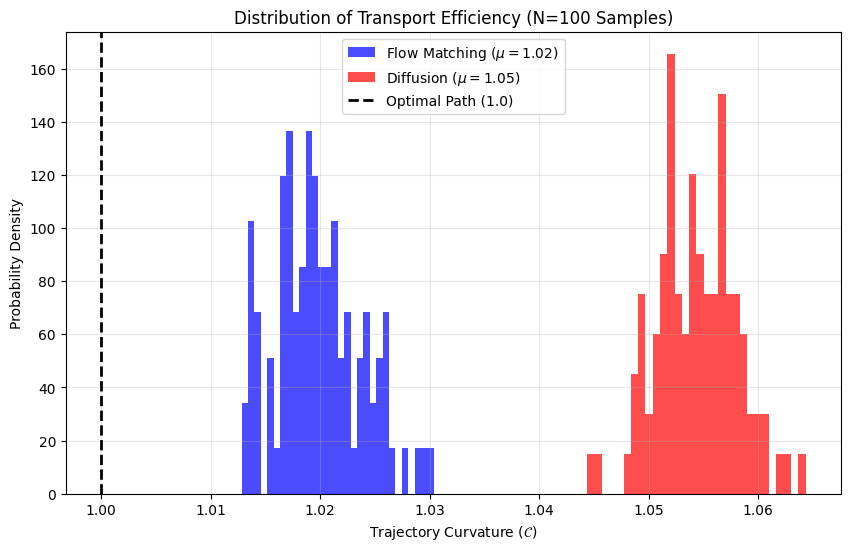

In [19]:
# FINAL PLOT

flow_data = [1.0156730488439856, 1.0235224542150847, 1.0163802843520762, 1.0166077831085758, 1.0234413371542976, 1.0293578846105442, 1.0210092164212459, 1.0196135768940915, 1.0303828192918867, 1.0180721185999684, 1.0128250871857234, 1.02176273380508, 1.0221945595060595, 1.0212179390785137, 1.0170266977047153, 1.0222276166255335, 1.0230661033688118, 1.025433247386009, 1.01904698117128, 1.0206025752131425, 1.0136445708569024, 1.0242563480510245, 1.0174865419490826, 1.0256634890916565, 1.0213350839883937, 1.0170979623415812, 1.0184785474843685, 1.0206917868748515, 1.013602955676849, 1.0275860168035271, 1.0199797930769836, 1.0172703947482051, 1.0170803391941492, 1.0134405247109721, 1.0137980550607766, 1.021275484026841, 1.023441098975323, 1.019008818205224, 1.01868668769146, 1.0137603575531133, 1.0212506291637853, 1.019155258579731, 1.0256882619025989, 1.019306465565017, 1.024560586090507, 1.0222665258982888, 1.0211299730454961, 1.019216549477039, 1.0199711757997145, 1.0175494329229688, 1.0145426054198137, 1.021901552229332, 1.0168645159105234, 1.0260835959858339, 1.0192677797615246, 1.0168247336364356, 1.0207496232962279, 1.0288953600081454, 1.0171776470653722, 1.0130257635707012, 1.0206076757827809, 1.013445906333852, 1.0265590774929014, 1.015364929511065, 1.0183413712336502, 1.0241740157204562, 1.0223044870146285, 1.0180344112164472, 1.0186931433658317, 1.0170301487102902, 1.0210242235994602, 1.0184424482233747, 1.0248402505014638, 1.0195338286997735, 1.0261707326445304, 1.0262561906222123, 1.0257853439813929, 1.0159164668218585, 1.0168903333620385, 1.0217082877499304, 1.0166662924662282, 1.0203327201141992, 1.0196715840453807, 1.0198343903930271, 1.0180150767939649, 1.015412177678548, 1.0192344763022707, 1.019007313005381, 1.0145754015633741, 1.0173733500418911, 1.0243779204971175, 1.020241224110321, 1.0200416993960908, 1.018338244774001, 1.0164114346290722, 1.0193641325549783, 1.0183933532722245, 1.0242993636576343, 1.0142061476865118, 1.0142029692603367]
diff_data = [1.062005691360747, 1.056357054889768, 1.0551479172474436, 1.0569359946100303, 1.052355022333815, 1.0553785945999672, 1.0582527482252464, 1.057445558749715, 1.0564200683276643, 1.0517266473348212, 1.055050559782829, 1.0511330476132477, 1.054884967238704, 1.0541237862796622, 1.0551730410280862, 1.0510567557417172, 1.0494151833302146, 1.0526747930488478, 1.0534064395886613, 1.052068859549504, 1.0527816745834566, 1.0575719659168563, 1.0488955987460171, 1.0599193419651007, 1.0452692821504421, 1.0542562360021908, 1.0566505930527508, 1.050533531316473, 1.0564235352527545, 1.0511076544039708, 1.0518244722235885, 1.0577392463719797, 1.0487956647716419, 1.0532069641242086, 1.051951738239158, 1.0568411161727955, 1.0591033820279743, 1.05497137632863, 1.057641685439643, 1.053862575617697, 1.0567072860839988, 1.0583664148120495, 1.0520326612543653, 1.0576433361238478, 1.058218204177618, 1.0535594347983426, 1.055947592313652, 1.0540921983814335, 1.0559156760073105, 1.0534469443058967, 1.0496075163843142, 1.0625708296088459, 1.0513004778823059, 1.0560823334392853, 1.0594933328161624, 1.0537314649877871, 1.0551287650788541, 1.0585533299445755, 1.0478994709948086, 1.0494133148562794, 1.0519119704901498, 1.0584405712694778, 1.0521388339946336, 1.0502076393897402, 1.0546091347954905, 1.0586422896992245, 1.056284000209872, 1.0544591971964077, 1.0537014813519097, 1.0578773219434843, 1.0564614573876936, 1.0443835453489427, 1.060405742692981, 1.054450754442249, 1.049948518774487, 1.05993701431403, 1.0539473521789773, 1.0643086190953612, 1.050985166183514, 1.0511376056448392, 1.0565360412917038, 1.051079600520952, 1.0518701110991209, 1.048724689105342, 1.05465182837154, 1.052922497086869, 1.0507616954525323, 1.0582464380831471, 1.0519257670788822, 1.0520686739884908, 1.0608392604323624, 1.057239727201874, 1.0490409409004535, 1.0519091383978758, 1.0568630650058832, 1.0509184946016075, 1.0496844108221062, 1.0526965431218704, 1.0558099460740156, 1.053831774171108]

# Conversion to numpy for plotting
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.hist(flow_data, bins=30, alpha=0.7, label=f'Flow Matching ($\mu={np.mean(flow_data):.2f}$)', color='blue', density=True)
plt.hist(diff_data, bins=30, alpha=0.7, label=f'Diffusion ($\mu={np.mean(diff_data):.2f}$)', color='red', density=True)

plt.axvline(x=1.0, color='k', linestyle='--', linewidth=2, label='Optimal Path (1.0)')
plt.xlabel("Trajectory Curvature ($\mathcal{C}$)")
plt.ylabel("Probability Density")
plt.title("Distribution of Transport Efficiency (N=100 Samples)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig("curvature_histogram.png")
plt.show()

Running Numerical Solver Analysis


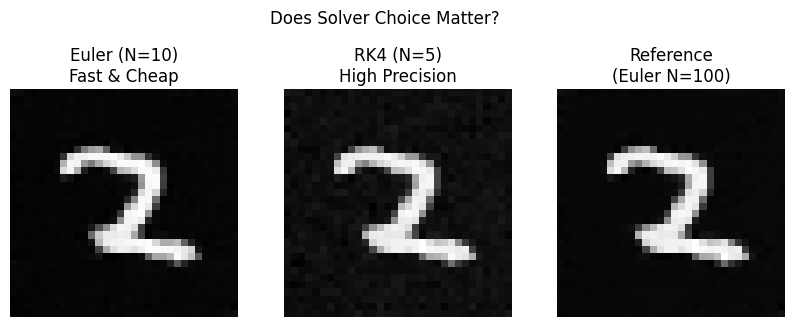

In [22]:
# SOLVER SENSITIVITY ANALYSIS
import matplotlib.pyplot as plt

@torch.no_grad()
def ode_solve(model, x_init, steps, method="euler"):
    """
    Solves the ODE. Returns the result on CPU to prevent plotting errors.
    """
    x = x_init.clone()
    dt = 1.0 / steps
    model.eval()

    for i in range(steps):
        t_val = i / steps
        t = torch.ones(1, device=DEVICE) * t_val

        if method == "euler":
            # x_{n+1} = x_n + h * f(t, x_n)
            v = model(x, t)
            x = x + v * dt

        elif method == "rk4":
            # Runge-Kutta 4th Order
            k1 = model(x, t)

            t_half = torch.ones(1, device=DEVICE) * (t_val + 0.5*dt)
            k2 = model(x + 0.5 * dt * k1, t_half)
            k3 = model(x + 0.5 * dt * k2, t_half)

            t_next = torch.ones(1, device=DEVICE) * (t_val + dt)
            k4 = model(x + dt * k3, t_next)

            x = x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return x.cpu() # Force move to CPU before returning

@torch.no_grad()
def compare_solvers(model):
    print("Running Numerical Solver Analysis")
    torch.manual_seed(42)
    x_init = torch.randn(1, 1, 32, 32).to(DEVICE)

    # Euler @ 10 Steps
    img_e10 = ode_solve(model, x_init, steps=10, method="euler")

    # RK4 @ 5 Steps
    img_rk5 = ode_solve(model, x_init, steps=5, method="rk4")

    # Ground Truth (Euler @ 100 Steps)
    img_gt = ode_solve(model, x_init, steps=100, method="euler")

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(10, 4))

    # Added .cpu() here as a double safety measure
    ax[0].imshow(img_e10[0,0].cpu(), cmap='gray')
    ax[0].set_title("Euler (N=10)\nFast & Cheap")

    ax[1].imshow(img_rk5[0,0].cpu(), cmap='gray')
    ax[1].set_title("RK4 (N=5)\nHigh Precision")

    ax[2].imshow(img_gt[0,0].cpu(), cmap='gray')
    ax[2].set_title("Reference\n(Euler N=100)")

    for a in ax: a.axis('off')
    plt.suptitle("Does Solver Choice Matter?")
    plt.savefig("solver_comparison.png")
    plt.show()

if MODE == "FLOW":
    compare_solvers(model)
else:
    print(" Please load FLOW mode first")